# Introduction

In computational linguistics and computational biology, the concept of edit distance plays a key role in quantifying the dissimilarity between two strings. Edit distance, also known as Levenshtein distance, measures the minimum number of single-character operations (insertions, deletions, or substitutions) required to transform one string into another. This assignment delves into the fundamental principles of edit distance, its significance in various applications, and explores the dynamic programming algorithm that underlies its computation. Join us on a journey to understand how edit distance facilitates tasks such as spell checking, DNA sequence alignment, and beyond. Let's unravel the intricacies of edit distance and appreciate its broad impact on diverse domains.








In [22]:
import sys
!{sys.executable} -m pip install prettytable

In [23]:
from prettytable import PrettyTable



### <span style="color:red"><b>Problem 1</b></span>

Compute the edit distance between the strings `leda` and `deal` using the following costs:

- Insertion cost: 1
- Deletion cost: 1
- Substitution cost: 2

Show your step-by-step calculations using the edit distance grid by hand. After completing the calculations, replace the file `
hand_solution1.png` with an image of your handwritten solution. This will be displayed in the notebook to illustrate your process.



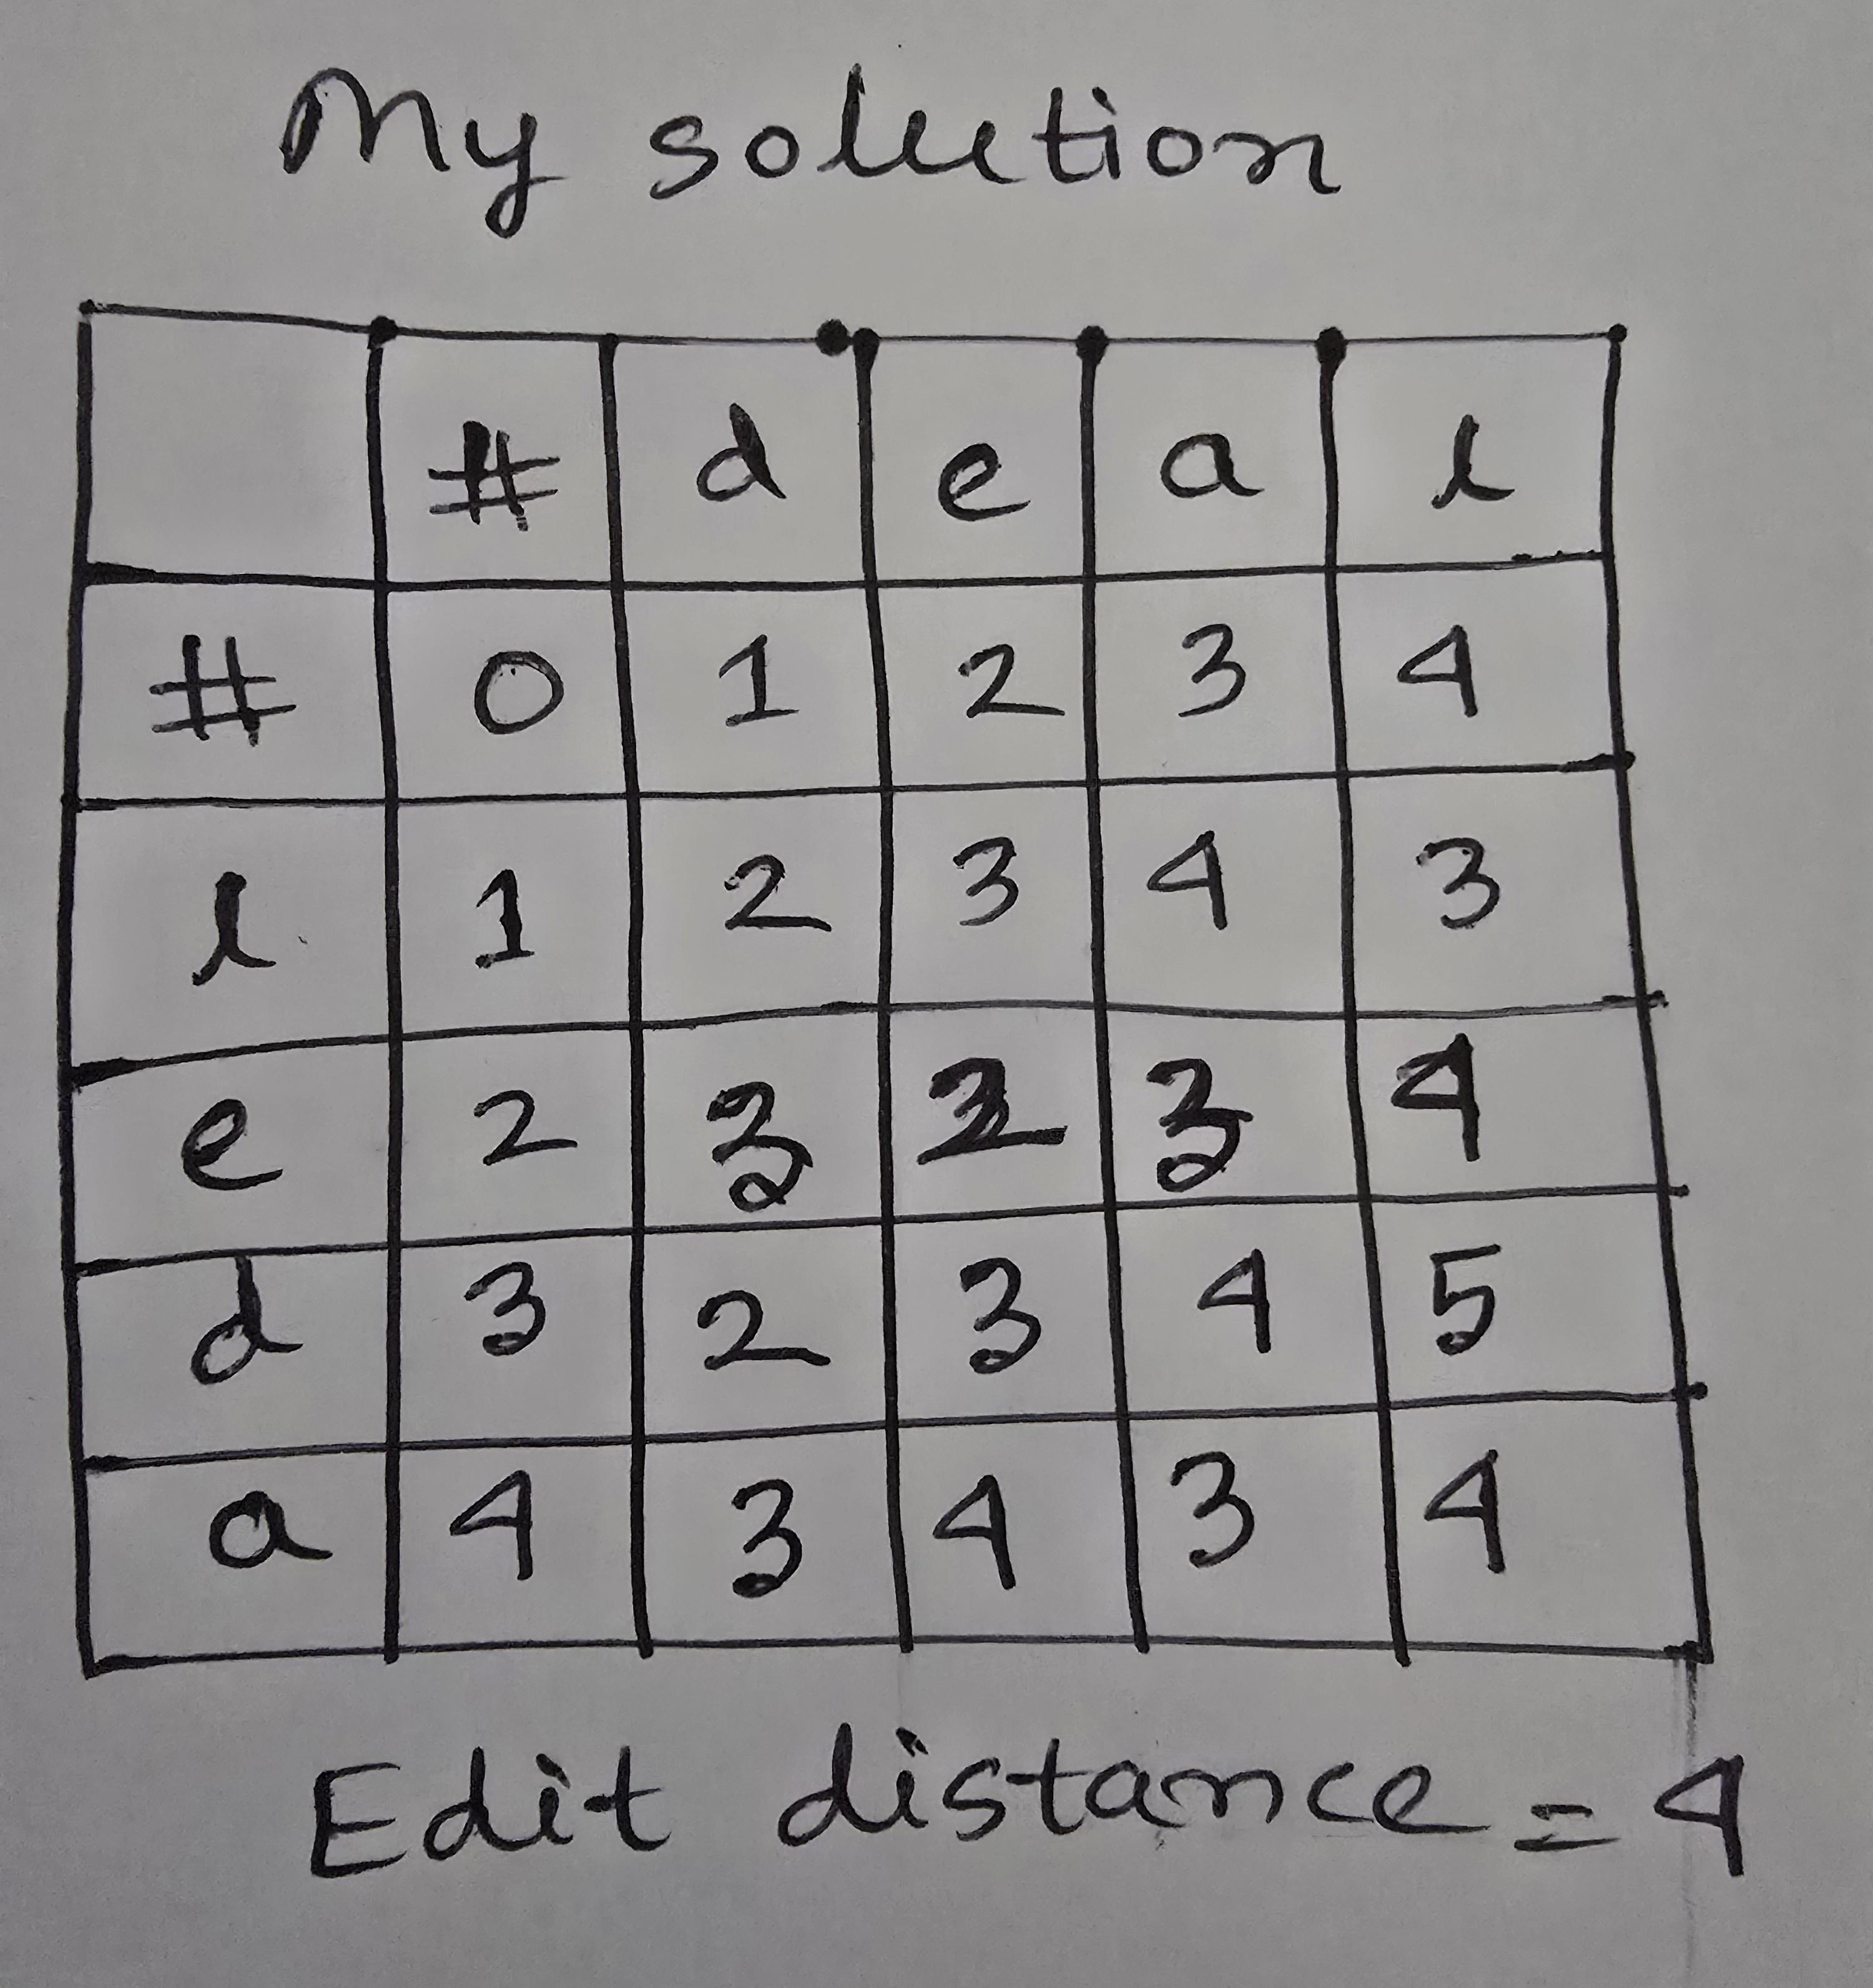

In [24]:
from IPython.display import display, Image

file_name = 'hand_solution1.jpg'
display(Image(filename=file_name, width=600))


### <span style="color:red"><b>Problem 2</b></span>

Figure out whether `drive` is closer to `brief` or to `divers` and what the edit distance is to each (using insertion cost 1, deletion cost 1, substitution cost 2). Report your solution by hand and replace the file `hand_solution2.pnd`.

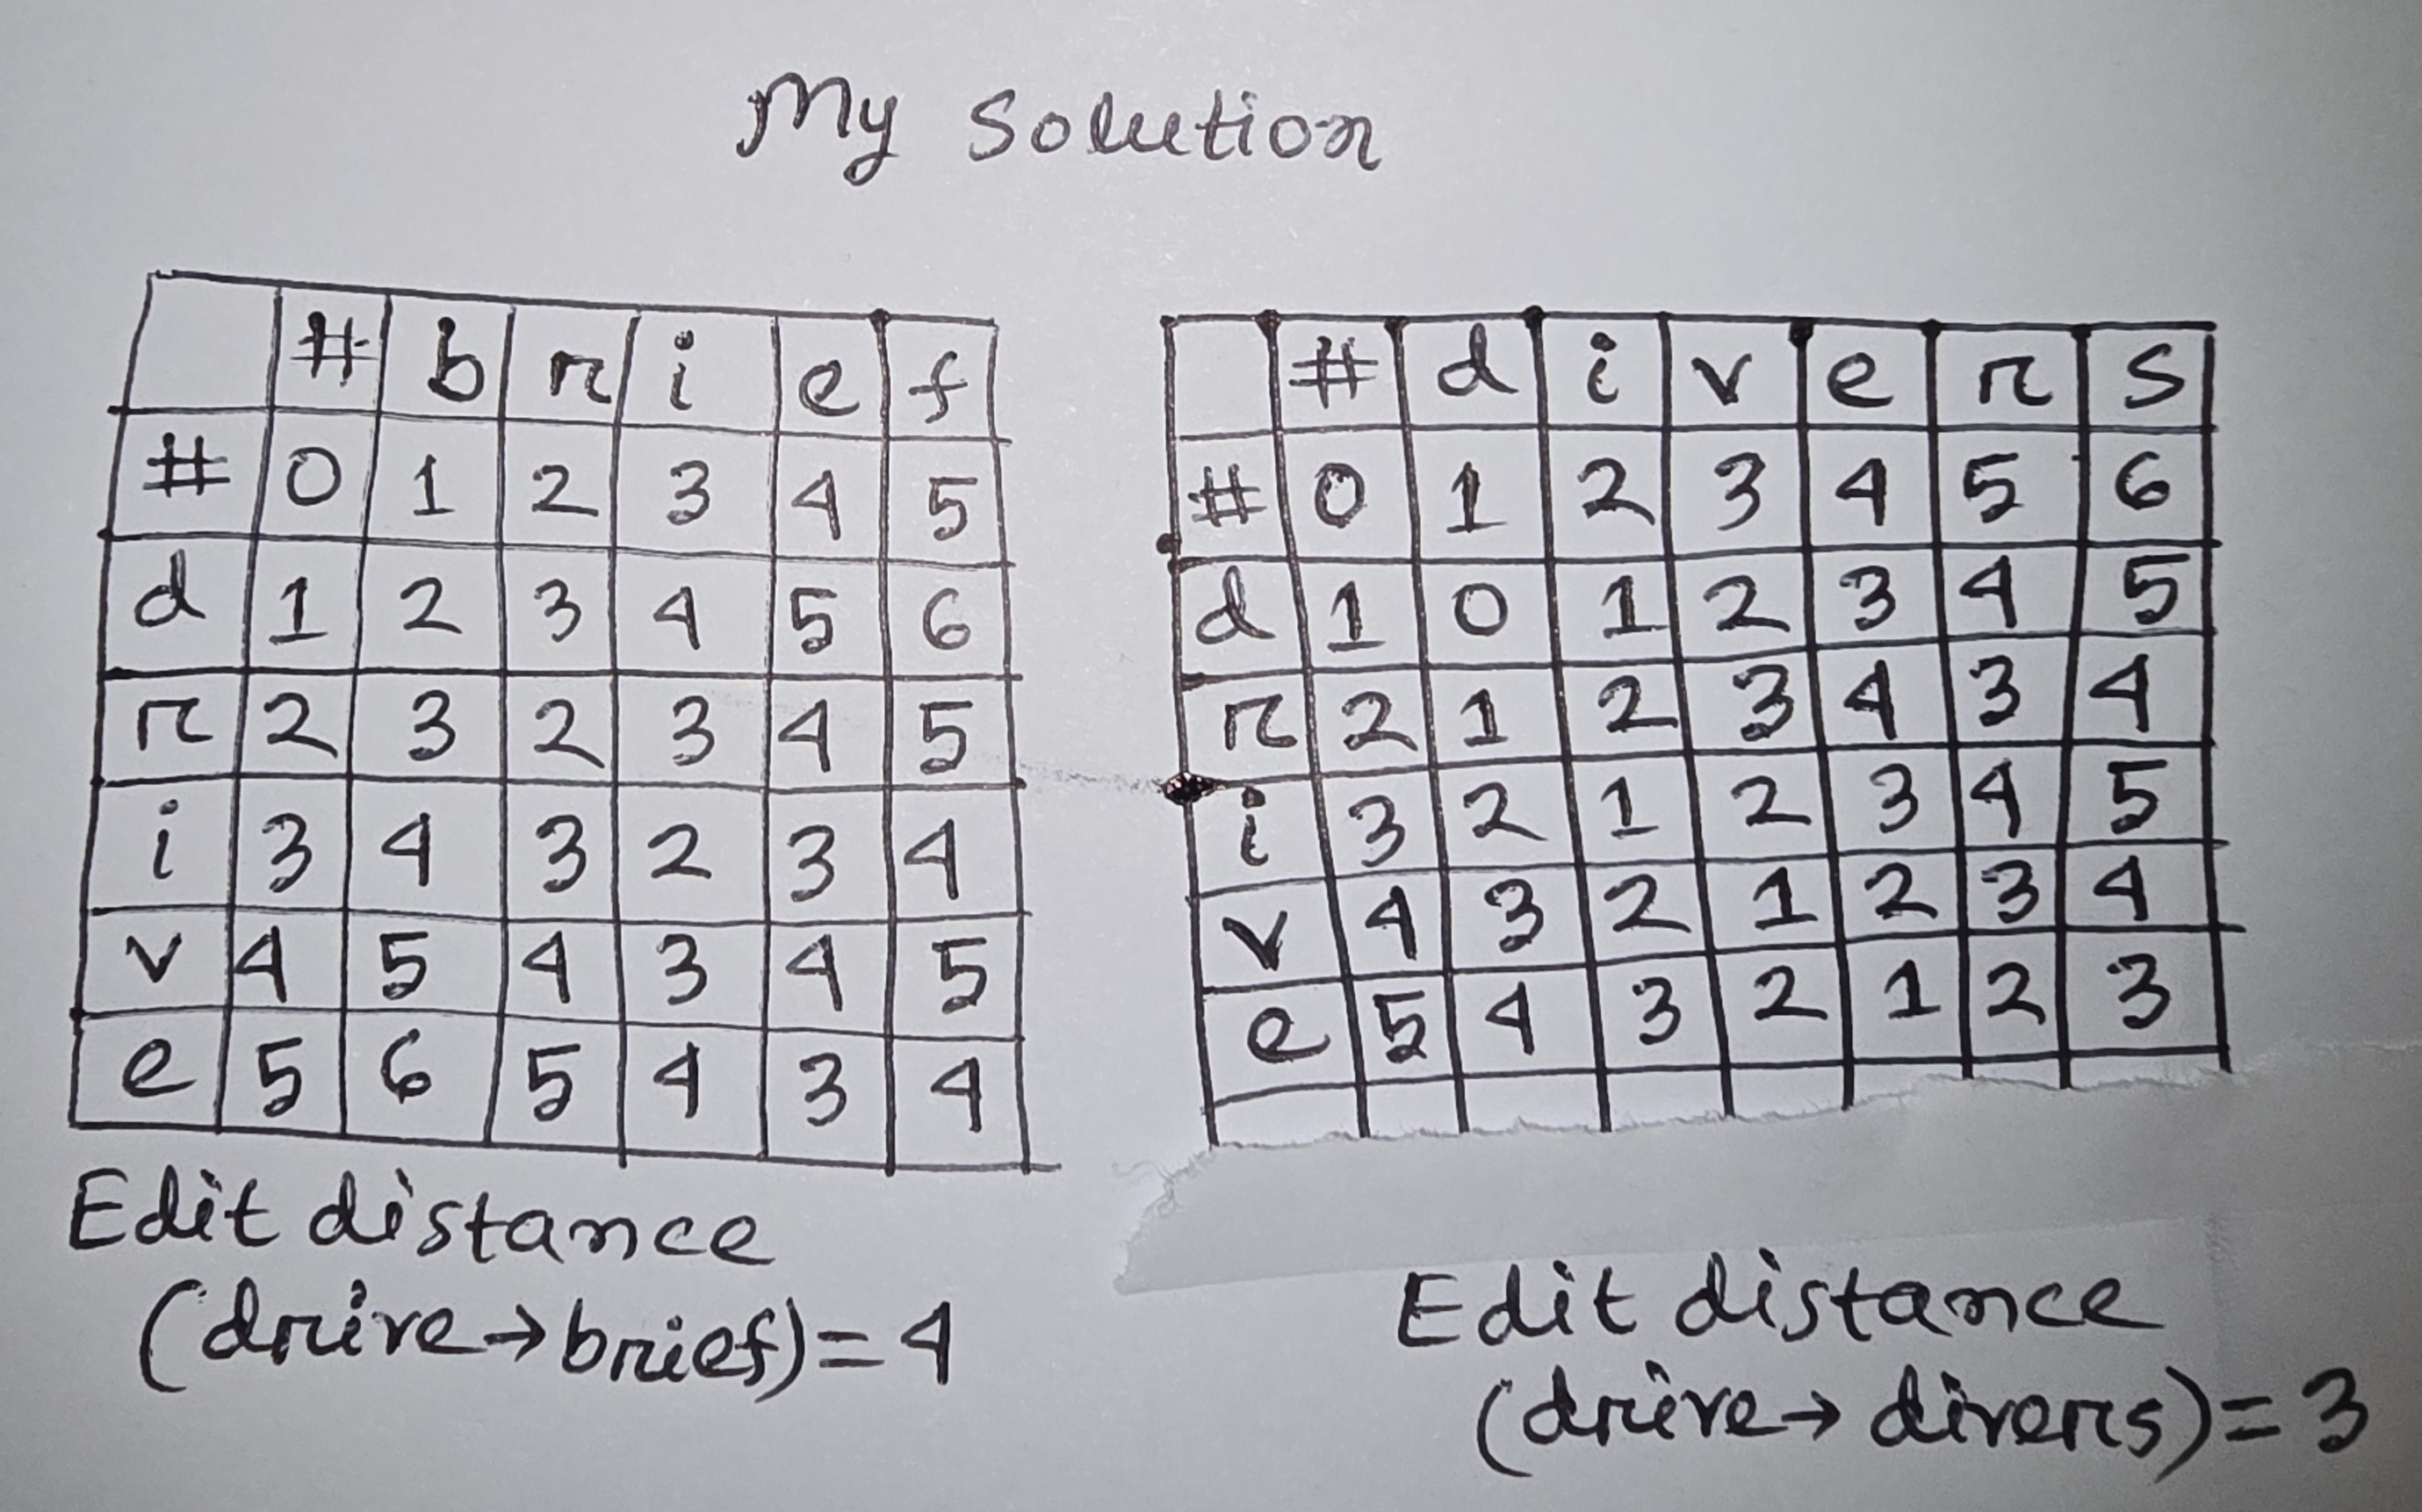

In [25]:
from IPython.display import display, Image

file_name = 'hand_solution2.jpg'
display(Image(filename=file_name, width=600))


### <span style="color:red"><b>Problem 3</b></span>

Now implement a minimum edit distance algorithm and use your hand-computed results to check your code.
Your code should also print the `The Edit Distance Table` seen in the lecture. Use the `prettytable` library for that.


In [26]:
def levenshtein_distance(str1, str2, print_table = True):    
    len_str1, len_str2 = len(str1), len(str2)
    # Initialize a matrix to store the distances
    distance_matrix = [[0] * (len_str2 + 1) for _ in range(len_str1 + 1)]
    ## START YOU CODE HERE
    # Initialize
    for i in range(len_str1 + 1):
        distance_matrix[i][0] = i

    for j in range(len_str2 + 1):
        distance_matrix[0][j] = j

    # Fill
    for i in range(1, len_str1 + 1):
        for j in range(1, len_str2 + 1):

            if str1[i-1] == str2[j-1]:
                cost = 0
            else:
                cost = 2

            distance_matrix[i][j] = min(
                distance_matrix[i-1][j] + 1,
                distance_matrix[i][j-1] + 1,
                distance_matrix[i-1][j-1] + cost
            )

    # Print table
    if print_table:
        table = PrettyTable()
        
        
        table.field_names = [" "] + ["#"] + [f"{c}{i}" for i, c in enumerate(str2)]

        for i in range(len_str1 + 1):
            row_label = "#" if i == 0 else str1[i-1]
            row = [row_label] + distance_matrix[i]
            table.add_row(row)

        print(table)

    return distance_matrix[len_str1][len_str2]
    ## END


Run this cell to test your code against the example above.

In [27]:
str1 = "drive"
str2 = "brief"
distance = levenshtein_distance(str1, str2)
print(f"Levenshtein distance between '{str1}' and '{str2}': {distance}")

# Example usage:
str1 = "drive"
str2 = "divers"
distance = levenshtein_distance(str1, str2)
print(f"Levenshtein distance between '{str1}' and '{str2}': {distance}")


+---+---+----+----+----+----+----+
|   | # | b0 | r1 | i2 | e3 | f4 |
+---+---+----+----+----+----+----+
| # | 0 | 1  | 2  | 3  | 4  | 5  |
| d | 1 | 2  | 3  | 4  | 5  | 6  |
| r | 2 | 3  | 2  | 3  | 4  | 5  |
| i | 3 | 4  | 3  | 2  | 3  | 4  |
| v | 4 | 5  | 4  | 3  | 4  | 5  |
| e | 5 | 6  | 5  | 4  | 3  | 4  |
+---+---+----+----+----+----+----+
Levenshtein distance between 'drive' and 'brief': 4
+---+---+----+----+----+----+----+----+
|   | # | d0 | i1 | v2 | e3 | r4 | s5 |
+---+---+----+----+----+----+----+----+
| # | 0 | 1  | 2  | 3  | 4  | 5  | 6  |
| d | 1 | 0  | 1  | 2  | 3  | 4  | 5  |
| r | 2 | 1  | 2  | 3  | 4  | 3  | 4  |
| i | 3 | 2  | 1  | 2  | 3  | 4  | 5  |
| v | 4 | 3  | 2  | 1  | 2  | 3  | 4  |
| e | 5 | 4  | 3  | 2  | 1  | 2  | 3  |
+---+---+----+----+----+----+----+----+
Levenshtein distance between 'drive' and 'divers': 3


Run this cell to test your code against the example discussed in the lecture.

In [28]:
str1 = "intention"
str2 = "execution"
assert levenshtein_distance(str1, str2) == 8, "Test failed!"
print("Success!")


+---+---+----+----+----+----+----+----+----+----+----+
|   | # | e0 | x1 | e2 | c3 | u4 | t5 | i6 | o7 | n8 |
+---+---+----+----+----+----+----+----+----+----+----+
| # | 0 | 1  | 2  | 3  | 4  | 5  | 6  | 7  | 8  | 9  |
| i | 1 | 2  | 3  | 4  | 5  | 6  | 7  | 6  | 7  | 8  |
| n | 2 | 3  | 4  | 5  | 6  | 7  | 8  | 7  | 8  | 7  |
| t | 3 | 4  | 5  | 6  | 7  | 8  | 7  | 8  | 9  | 8  |
| e | 4 | 3  | 4  | 5  | 6  | 7  | 8  | 9  | 10 | 9  |
| n | 5 | 4  | 5  | 6  | 7  | 8  | 9  | 10 | 11 | 10 |
| t | 6 | 5  | 6  | 7  | 8  | 9  | 8  | 9  | 10 | 11 |
| i | 7 | 6  | 7  | 8  | 9  | 10 | 9  | 8  | 9  | 10 |
| o | 8 | 7  | 8  | 9  | 10 | 11 | 10 | 9  | 8  | 9  |
| n | 9 | 8  | 9  | 10 | 11 | 12 | 11 | 10 | 9  | 8  |
+---+---+----+----+----+----+----+----+----+----+----+
Success!


### <span style="color:red"><b>Problem 4</b></span>

Augment the minimum edit distance algorithm to output an alignment; **you will need to store pointers and add a stage to compute the backtrace**.

In [29]:
def levenshtein_distance_with_backtrace(str1, str2, print_table=True):
    len_str1, len_str2 = len(str1), len(str2)
    # Initialize a matrix to store the distances
    distance_matrix = [[0] * (len_str2 + 1) for _ in range(len_str1 + 1)]
    ## START YOU CODE HERE
    # Pointer matrix
    backtrace = [[None] * (len_str2 + 1) for _ in range(len_str1 + 1)]

    ## START YOU CODE HERE

    # Step 1: Initializing
    for i in range(len_str1 + 1):
        distance_matrix[i][0] = i
        backtrace[i][0] = "↑"

    for j in range(len_str2 + 1):
        distance_matrix[0][j] = j
        backtrace[0][j] = "←"

    backtrace[0][0] = None

    # Step 2: Filling matrix
    for i in range(1, len_str1 + 1):
        for j in range(1, len_str2 + 1):

            if str1[i-1] == str2[j-1]:
                cost = 0
            else:
                cost = 2

            delete = distance_matrix[i-1][j] + 1
            insert = distance_matrix[i][j-1] + 1
            substitute = distance_matrix[i-1][j-1] + cost

            min_cost = min(delete, insert, substitute)
            distance_matrix[i][j] = min_cost

            # Storing pointer
            if min_cost == substitute:
                backtrace[i][j] = "↖"
            elif min_cost == delete:
                backtrace[i][j] = "↑"
            else:
                backtrace[i][j] = "←"

    ## END

    # Step 3: Backtracing (alignment)
    i, j = len_str1, len_str2
    aligned_str1 = []
    aligned_str2 = []

    while i > 0 or j > 0:
        if backtrace[i][j] == "↖":
            aligned_str1.append(str1[i-1])
            aligned_str2.append(str2[j-1])
            i -= 1
            j -= 1

        elif backtrace[i][j] == "↑":
            aligned_str1.append(str1[i-1])
            aligned_str2.append("-")
            i -= 1

        elif backtrace[i][j] == "←":
            aligned_str1.append("-")
            aligned_str2.append(str2[j-1])
            j -= 1

    aligned_str1.reverse()
    aligned_str2.reverse()

    # Step 4: Building alignment with operations
    alignment = []

    for a, b in zip(aligned_str1, aligned_str2):
        if a == b:
            op = "match"
        elif a == "-":
            op = "insert"
        elif b == "-":
            op = "delete"
        else:
            op = "substitute"
        
        alignment.append((a, b, op))

    # Step 5: Printing table
    if print_table:
        table = PrettyTable()
        table.field_names = [" "] + ["#"] + [f"{c}{i}" for i, c in enumerate(str2)]

        for i in range(len_str1 + 1):
            row_label = "#" if i == 0 else str1[i-1]
            row = [row_label] + distance_matrix[i]
            table.add_row(row)

        print(table)

    # Step 6: Returning result
    return distance_matrix[len_str1][len_str2], alignment
    ## END


Run this cell to test your code against the example discussed in the lecture. 
**Note that there maybe multiple correct  allignments!**

In [30]:
# Example usage:
str1 = "intention"
str2 = "execution"
distance, alignment = levenshtein_distance_with_backtrace(str1, str2)

print(f"Levenshtein distance between '{str1}' and '{str2}': {distance}")
print("Alignment:")
for a, b, op in alignment:
    print(f"{a} -> {b} ({op})")

+---+---+----+----+----+----+----+----+----+----+----+
|   | # | e0 | x1 | e2 | c3 | u4 | t5 | i6 | o7 | n8 |
+---+---+----+----+----+----+----+----+----+----+----+
| # | 0 | 1  | 2  | 3  | 4  | 5  | 6  | 7  | 8  | 9  |
| i | 1 | 2  | 3  | 4  | 5  | 6  | 7  | 6  | 7  | 8  |
| n | 2 | 3  | 4  | 5  | 6  | 7  | 8  | 7  | 8  | 7  |
| t | 3 | 4  | 5  | 6  | 7  | 8  | 7  | 8  | 9  | 8  |
| e | 4 | 3  | 4  | 5  | 6  | 7  | 8  | 9  | 10 | 9  |
| n | 5 | 4  | 5  | 6  | 7  | 8  | 9  | 10 | 11 | 10 |
| t | 6 | 5  | 6  | 7  | 8  | 9  | 8  | 9  | 10 | 11 |
| i | 7 | 6  | 7  | 8  | 9  | 10 | 9  | 8  | 9  | 10 |
| o | 8 | 7  | 8  | 9  | 10 | 11 | 10 | 9  | 8  | 9  |
| n | 9 | 8  | 9  | 10 | 11 | 12 | 11 | 10 | 9  | 8  |
+---+---+----+----+----+----+----+----+----+----+----+
Levenshtein distance between 'intention' and 'execution': 8
Alignment:
i -> - (delete)
n -> e (substitute)
t -> x (substitute)
e -> e (match)
- -> c (insert)
n -> u (substitute)
t -> t (match)
i -> i (match)
o -> o (match)
n -> n 

# Congratulations!


Congratulations on completing the assignment! Your dedication and effort are commendable. By successfully working through the coding exercises and written exercises, you have demonstrated a strong understanding of the concepts and principles related to Edit Distance.


Congratulations on finishing this notebook! 




# Acknowledgement

## About the Author

This notebook was authored by Mohamed Reda Bouadjenek. He is a Senior Lecturer (Assistant Professor) of Applied Artificial Intelligence in the School of Information Technology at Deakin University, Australia.

## Contact Information

- **Email:** reda.bouadjenek@deakin.edu.au
- **GitHub:** https://github.com/rbouadjenek/

---
